In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Employers_data.csv")

In [5]:
df.head(10)

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000
5,6,Michael Irving,35,Male,Finance,Manager,8,PhD,New York,125000
6,7,Marcelle Campbell,23,Female,Marketing,Analyst,2,Bachelor,San Francisco,60000
7,8,Glenda Leal,47,Female,Marketing,Manager,24,Master,San Francisco,145000
8,9,Walter Williams,43,Male,Marketing,Manager,16,PhD,San Francisco,135000
9,10,Vanessa Songer,23,Female,Marketing,Analyst,0,Master,San Francisco,70000


In [6]:
print(df.shape)

(10000, 10)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 546.9+ KB


In [8]:
df.isnull().sum()

Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

In [9]:
df.describe()

,Employee_ID,Age,Experience_Years,Salary
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.455900,12.370900,115381.500000
std,2886.89568,10.000213,9.148951,46066.139047
min,1.00000,21.000000,0.000000,25000.000000
25%,2500.75000,27.000000,5.000000,70000.000000
50%,5000.50000,34.000000,10.000000,120000.000000
75%,7500.25000,43.000000,19.000000,150000.000000
max,10000.00000,60.000000,37.000000,215000.000000


In [11]:
df.drop_duplicates(inplace=True)

In [13]:
df.ffill(inplace=True)

In [14]:
df["Performance_Score"] = (
    (df["Experience_Years"]*4)
    + (df["Salary"]/10000)
)

df["Performance_Score"] = df["Performance_Score"].clip(20,100)

In [15]:
dept_perf = df.groupby("Department")["Performance_Score"].mean()

print(dept_perf)

Department
Engineering    48.009507
Finance        65.302194
HR             62.966265
Marketing      50.875374
Product        60.630800
Sales          59.539844
Name: Performance_Score, dtype: float64


In [16]:
top10 = df.sort_values(
    by="Performance_Score",
    ascending=False
)

top10.head(10)

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary,Performance_Score
5216,5217,Andre Thomas,60,Male,Finance,Executive,33,PhD,San Francisco,205000,100.0
1365,1366,Trisha Lorentz,52,Female,Sales,Executive,25,PhD,New York,190000,100.0
1378,1379,Laura Gillard,49,Female,Product,Manager,26,Master,Seattle,145000,100.0
4973,4974,Antonio Hillman,47,Male,Engineering,Manager,24,Master,New York,145000,100.0
4977,4978,Allison Gardner,45,Female,HR,Manager,22,Master,Austin,135000,100.0
4979,4980,Patrice Whitfill,55,Female,HR,Executive,28,PhD,Chicago,195000,100.0
4981,4982,Kevin Torelli,56,Male,Sales,Executive,33,Master,New York,195000,100.0
2225,2226,Michael Pritchard,49,Male,Product,Manager,22,PhD,Chicago,150000,100.0
4991,4992,Ruby White,55,Female,Sales,Executive,32,Master,Seattle,190000,100.0
9594,9595,Nancy Grossmann,53,Female,HR,Executive,30,Master,Chicago,195000,100.0


In [17]:
df["Performance_Score"].describe()

count    10000.000000
mean        57.829150
std         30.716361
min         20.000000
25%         27.000000
50%         53.500000
75%         90.000000
max        100.000000
Name: Performance_Score, dtype: float64

In [18]:
df["Experience_Years"].corr(
    df["Performance_Score"]
)

np.float64(0.9598886638990415)

In [19]:
df[["Salary","Performance_Score"]].corr()

,Salary,Performance_Score
Salary,1.000000,0.901965
Performance_Score,0.901965,1.000000


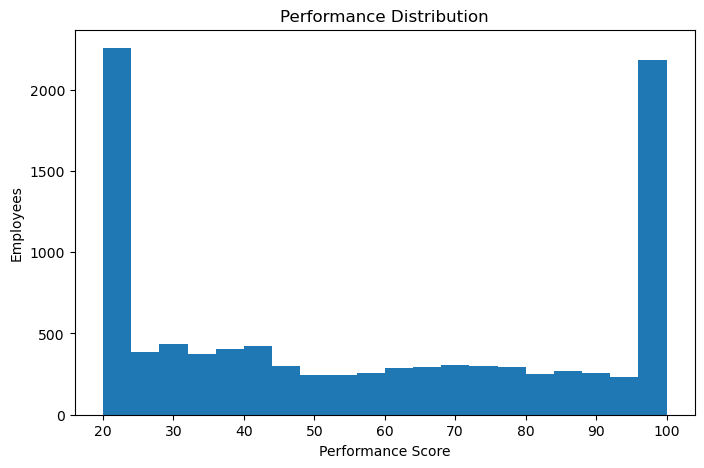

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Performance_Score"], bins=20)

plt.title("Performance Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Employees")

plt.show()

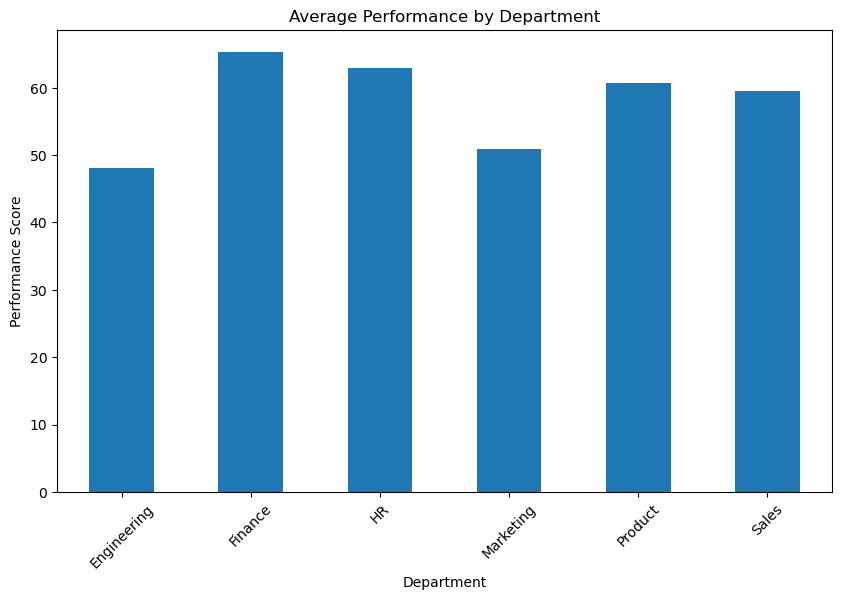

In [28]:
plt.figure(figsize=(10,6))

dept_perf.plot(kind="bar")

plt.title("Average Performance by Department")

plt.xlabel("Department")

plt.ylabel("Performance Score")

plt.xticks(rotation=45)

plt.show()

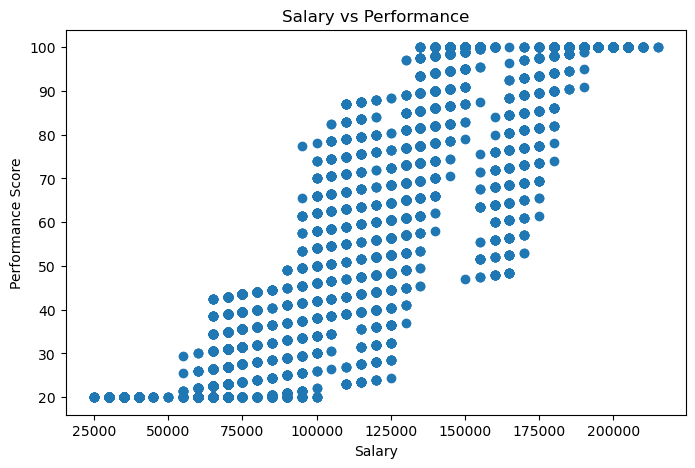

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["Salary"], df["Performance_Score"])

plt.title("Salary vs Performance")
plt.xlabel("Salary")
plt.ylabel("Performance Score")

plt.show()

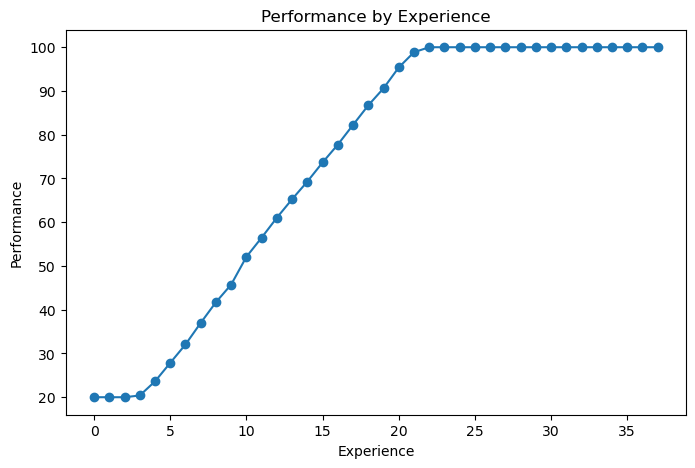

In [31]:
line = df.groupby(
    "Experience_Years"
)["Performance_Score"].mean()

plt.figure(figsize=(8,5))

line.plot(marker="o")

plt.title("Performance by Experience")

plt.xlabel("Experience")

plt.ylabel("Performance")

plt.show()

In [32]:
df.to_csv(
    "cleaned_employee_data.csv",
    index=False
)